In [ ]:
!pip install kaggle

In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
import os
file_name = '/content/handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [ ]:
len(data_0)

2236

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
dataset_path = "/kaggle/input/handwritten-digits-0-9/dataset"
X = []
y = []

dataset_path = os.path.join('/content', extract_folder)

for label in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, label)
    if not folder:
        continue

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        # load gambar 28x28 grayscale
        img = load_img(img_path, color_mode="grayscale", target_size=(28, 28))
        img = img_to_array(img)

        # normalisasi dan append
        X.append(img / 255.0)
        y.append(int(label))

In [ ]:
X = np.array(X)
y = np.array(y)
X = X.reshape(len(X), 28 * 28)
y_cat = to_categorical(y, 10)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)
print("Jumlah data training:", X_train.shape)
print("Jumlah data testing :", X_test.shape)

Jumlah data training: (17244, 784)
Jumlah data testing : (4311, 784)


In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')   # output 10 kelas (0-9)
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
 #TRAINING MODEL
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1232 - loss: 2.3525 - val_accuracy: 0.1722 - val_loss: 2.2092
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2460 - loss: 2.1217 - val_accuracy: 0.3148 - val_loss: 1.9786
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3453 - loss: 1.9070 - val_accuracy: 0.3606 - val_loss: 1.8196
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3981 - loss: 1.7812 - val_accuracy: 0.4104 - val_loss: 1.7414
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4371 - loss: 1.7051 - val_accuracy: 0.3983 - val_loss: 1.7760
Epoch 6/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4504 - loss: 1.6566 - val_accuracy: 0.4203 - val_loss: 1.7568
Epoch 7/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4521 - loss: 1.6208 - val_accuracy: 0.4151 - val_loss: 1.6787
Epoch 8/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4888 - loss: 1.5380 - val_accuracy: 0

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5478 - loss: 1.3407
Test Accuracy = 0.5479007363319397
Test Loss     = 1.3230990171432495


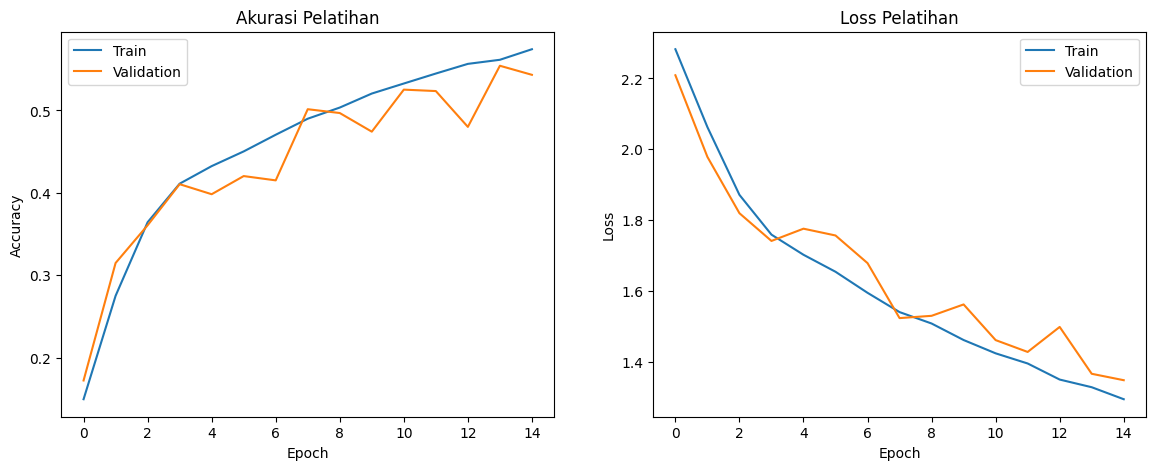

In [ ]:
# 4. EVALUASI MODEL
# -----------------------------------------------------------
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy =", acc)
print("Test Loss     =", loss)

# plot grafik akurasi & loss
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Akurasi Pelatihan")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Pelatihan")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


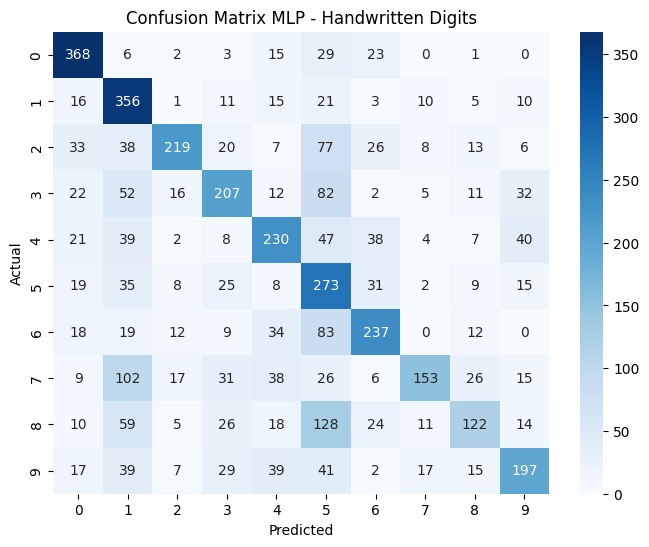


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       447
           1       0.48      0.79      0.60       448
           2       0.76      0.49      0.60       447
           3       0.56      0.47      0.51       441
           4       0.55      0.53      0.54       436
           5       0.34      0.64      0.44       425
           6       0.60      0.56      0.58       424
           7       0.73      0.36      0.48       423
           8       0.55      0.29      0.38       417
           9       0.60      0.49      0.54       403

    accuracy                           0.55      4311
   macro avg       0.59      0.54      0.54      4311
weighted avg       0.59      0.55      0.54      4311



In [ ]:
# CONFUSION MATRIX
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix MLP - Handwritten Digits")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))